# Project 3
**Alexander Gréus, Spencer Smith**

Chosen method: **K-Means**  
Goodness measure: **Silhouette Score** (ranges from -1 to 1; higher = better-defined clusters)

## Imports & Setup

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import os

# Output folder for cluster CSVs
os.makedirs("cluster_outputs", exist_ok=True)

print("Setup complete!")

Setup complete!


## Helper Functions

In [40]:
def find_best_k(data, k_range=range(2, 9)):
    """Use silhouette score to find the best k for K-Means."""
    scores = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(data)
        scores[k] = silhouette_score(data, labels)
    best_k = max(scores, key=scores.get)
    return best_k, scores


def run_kmeans_and_save_results(df, dataset_name, k):
    """Run K-Means with k-1, k, k+1 and save cluster CSVs."""
    data = df.values
    cols = df.columns.tolist()
    is_3d = len(cols) == 3

    results = {}
    for n in [k - 1, k, k + 1]:
        if n < 2:
            continue
        km = KMeans(n_clusters=n, random_state=42, n_init=10)
        labels = km.fit_predict(data)
        score = silhouette_score(data, labels)
        results[n] = {"labels": labels, "score": score, "model": km}

        for cluster_id in range(n):
            cluster_df = df[labels == cluster_id]
            fname = f"cluster_outputs/{dataset_name}_k{n}_cluster{cluster_id}.csv"
            cluster_df.to_csv(fname, index=False)

    return results


def plot_clusters(df, labels, title):
    """Scatter plot for 2D datasets."""
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(df["x"], df["y"], c=labels, cmap="tab10", s=20)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.colorbar(scatter, label="Cluster")
    plt.tight_layout()
    plt.savefig(f'plots/{title.split("(")[0].replace(" ", "").replace("–", "_").replace("=", "")}.png', transparent=True)
    plt.show()


def plot_clusters_3d(df, labels, title):
    """Scatter plot for 3D datasets."""
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(projection='3d')
    scatter = ax.scatter(
	    df["x"],
	    df["y"],
	    df["z"],
	    c=labels,
	    cmap="tab10",
	    s=20
	)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    plt.colorbar(scatter, label="Cluster", pad=.1)
    plt.tight_layout()
    plt.savefig(f'plots/{title.split("(")[0].replace(" ", "").replace("–", "_").replace("=", "")}.png', transparent=True)
    plt.show()


def plot_silhouette_curve(scores_dict, dataset_name):
    """Plot silhouette scores across k values."""
    ks = sorted(scores_dict.keys())
    sils = [scores_dict[k] for k in ks]
    plt.figure(figsize=(5, 3))
    plt.plot(ks, sils, marker="o")
    plt.title(f"{dataset_name} – Silhouette Score vs k")
    plt.xlabel("k")
    plt.ylabel("Silhouette Score")
    plt.xticks(ks)
    plt.tight_layout()
    plt.savefig(f'plots/{dataset_name.replace(" ", "")}_Silhouette.png', transparent=True)
    plt.show()


print("Helper functions defined!")

Helper functions defined!


## Dataset 1

Dataset 1: 200 points
                x           y
count  200.000000  200.000000
mean     8.029950    8.178000
std      2.228592    2.280452
min      3.440000    3.430000
25%      6.100000    6.112500
50%      8.205000    8.505000
75%      9.857500   10.100000
max     12.300000   13.000000


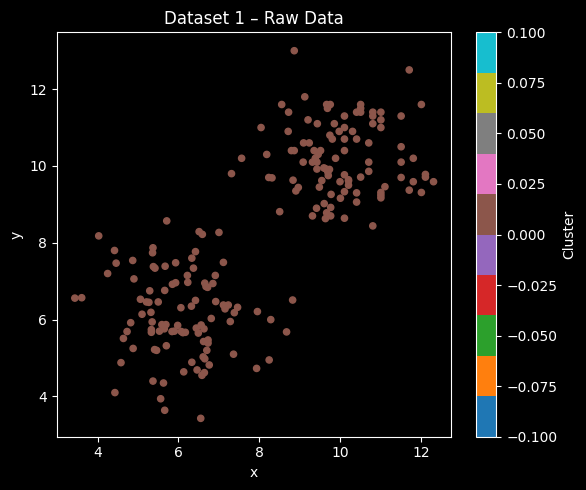

In [41]:
# --- Load ---
df1 = pd.read_csv("Dataset 1.csv", header=None, names=["x", "y"])
print(f"Dataset 1: {len(df1)} points")
print(df1.describe())

# Raw scatter
plot_clusters(df1, labels=[0]*len(df1), title="Dataset 1 – Raw Data")

Best k for Dataset 1: 2


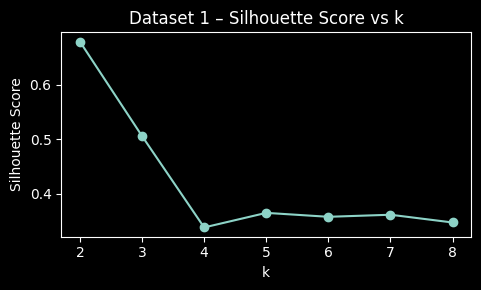

In [42]:
# Find best k
best_k1, scores1 = find_best_k(df1.values)
print(f"Best k for Dataset 1: {best_k1}")
plot_silhouette_curve(scores1, "Dataset 1")

  k=2  |  Silhouette Score: 0.6791


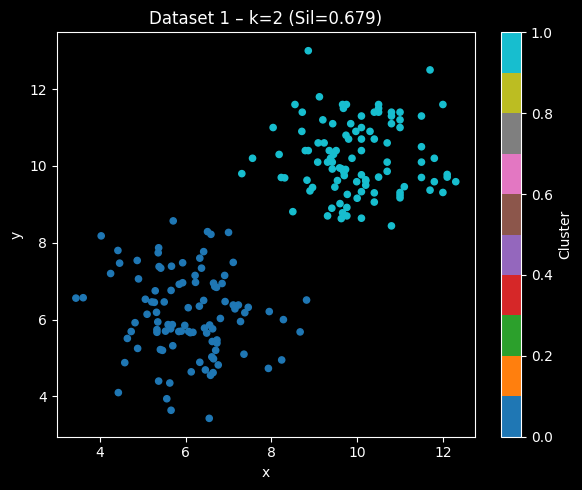

  k=3  |  Silhouette Score: 0.5058


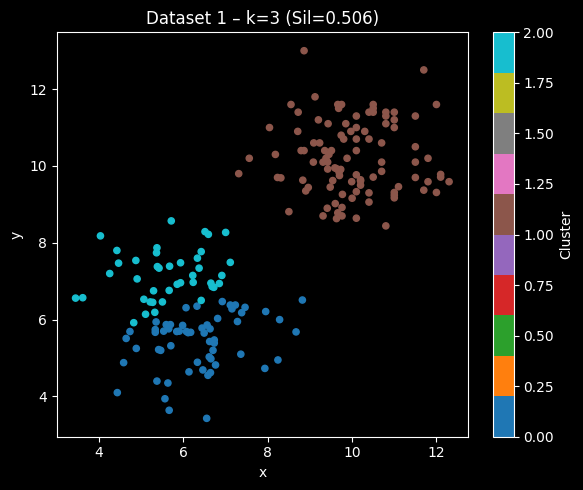

In [43]:
# Run K-Means and plot k-1, k, k+1
results1 = run_kmeans_and_save_results(df1, "Dataset1", best_k1)

for k, res in results1.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters(df1, res["labels"], f"Dataset 1 – k={k} (Sil={res['score']:.3f})")

## Dataset 2

Dataset 2: 200 points
Best k for Dataset 2: 2


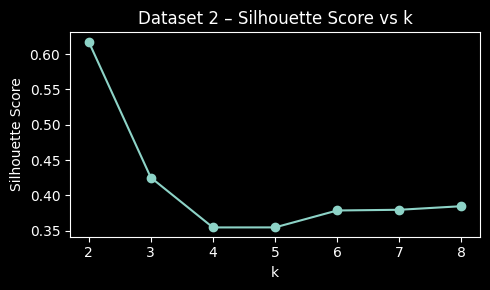

  k=2  |  Silhouette Score: 0.6178


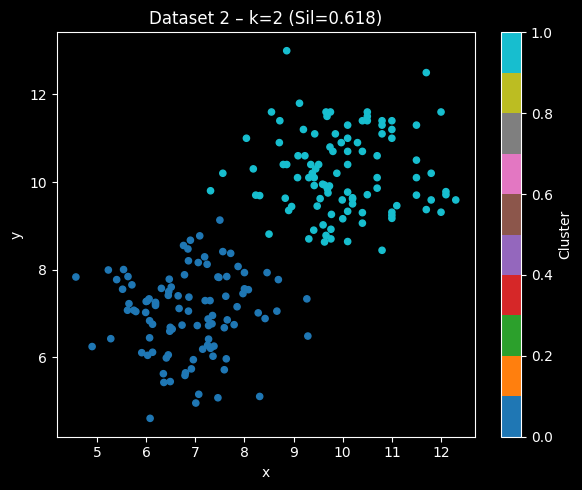

  k=3  |  Silhouette Score: 0.4253


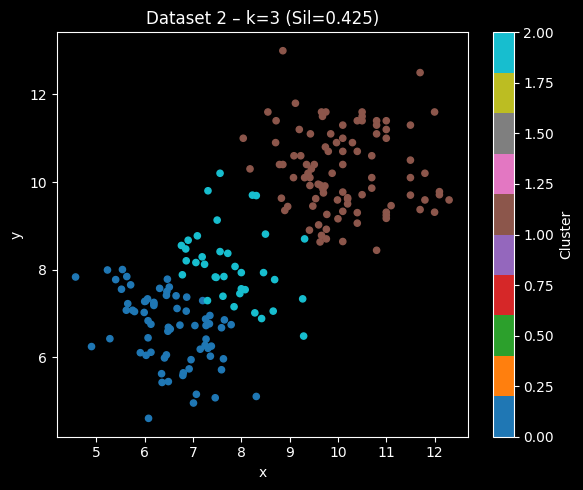

In [44]:
df2 = pd.read_csv("Dataset 2.csv", header=None, names=["x", "y"])
print(f"Dataset 2: {len(df2)} points")

best_k2, scores2 = find_best_k(df2.values)
print(f"Best k for Dataset 2: {best_k2}")
plot_silhouette_curve(scores2, "Dataset 2")

results2 = run_kmeans_and_save_results(df2, "Dataset2", best_k2)
for k, res in results2.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters(df2, res["labels"], f"Dataset 2 – k={k} (Sil={res['score']:.3f})")

## Dataset 3

Dataset 3: 1000 points
Best k for Dataset 3: 8


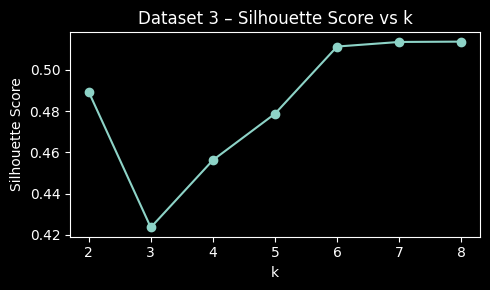

  k=7  |  Silhouette Score: 0.5135


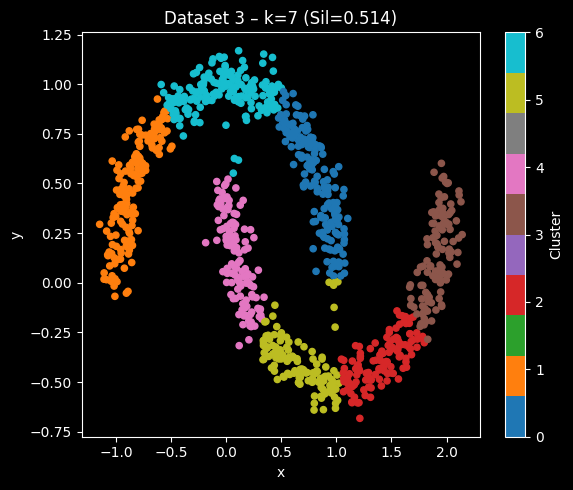

  k=8  |  Silhouette Score: 0.5137


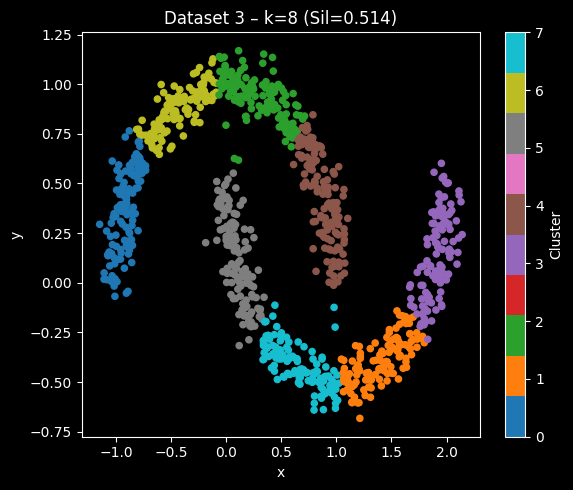

  k=9  |  Silhouette Score: 0.5141


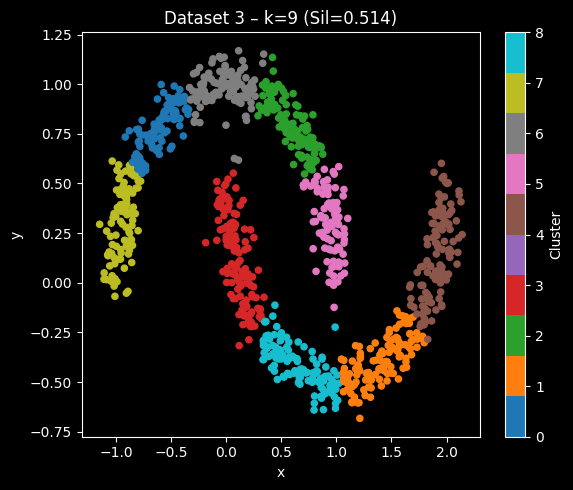

In [45]:
df3 = pd.read_csv("Dataset 3.csv", header=None, names=["x", "y"])
print(f"Dataset 3: {len(df3)} points")

best_k3, scores3 = find_best_k(df3.values)
print(f"Best k for Dataset 3: {best_k3}")
plot_silhouette_curve(scores3, "Dataset 3")

results3 = run_kmeans_and_save_results(df3, "Dataset3", best_k3)
for k, res in results3.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters(df3, res["labels"], f"Dataset 3 – k={k} (Sil={res['score']:.3f})")

## 6. Dataset 4

Dataset 4: 1000 points
Best k for Dataset 4: 7


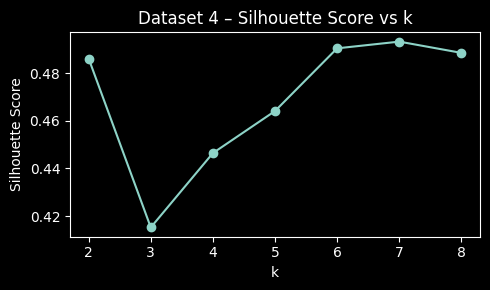

  k=6  |  Silhouette Score: 0.4904


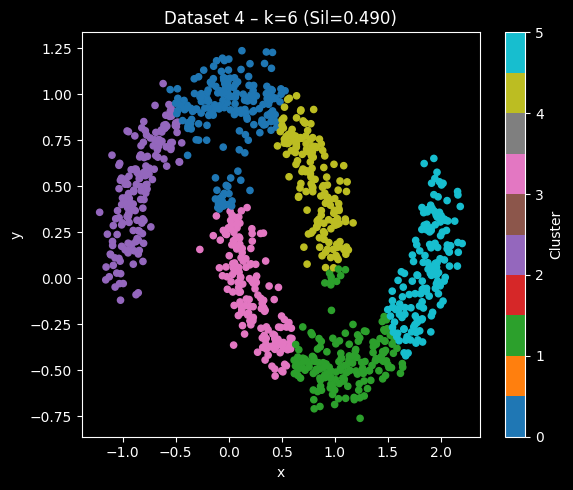

  k=7  |  Silhouette Score: 0.4932


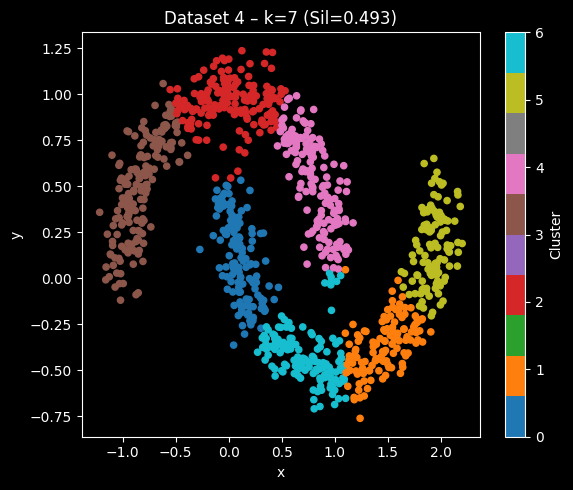

  k=8  |  Silhouette Score: 0.4885


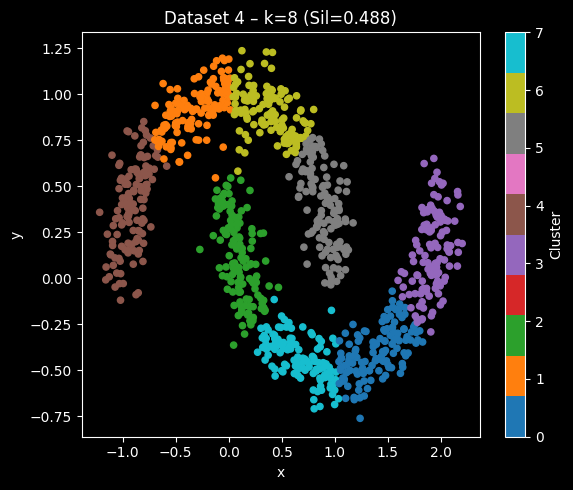

In [46]:
df4 = pd.read_csv("Dataset 4.csv", header=None, names=["x", "y"])
print(f"Dataset 4: {len(df4)} points")

best_k4, scores4 = find_best_k(df4.values)
print(f"Best k for Dataset 4: {best_k4}")
plot_silhouette_curve(scores4, "Dataset 4")

results4 = run_kmeans_and_save_results(df4, "Dataset4", best_k4)
for k, res in results4.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters(df4, res["labels"], f"Dataset 4 – k={k} (Sil={res['score']:.3f})")

## 7. Dataset 5

Dataset 5: 400 points
Best k for Dataset 5: 4


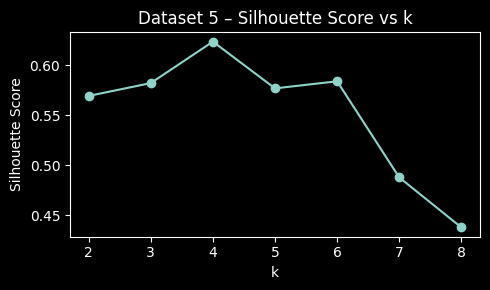

  k=3  |  Silhouette Score: 0.5821


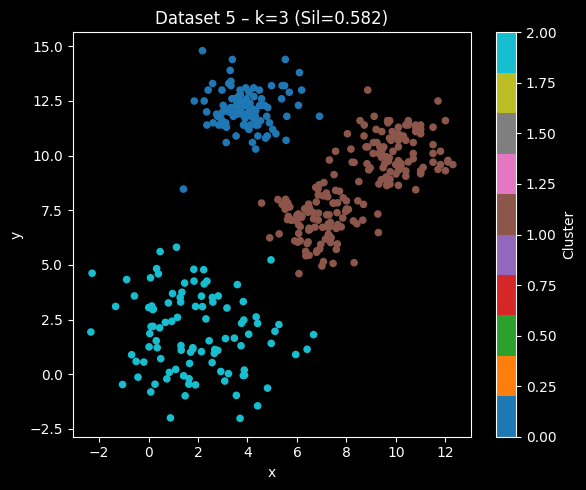

  k=4  |  Silhouette Score: 0.6235


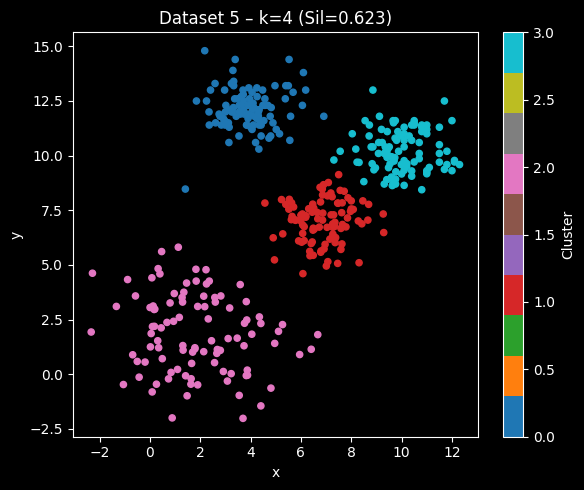

  k=5  |  Silhouette Score: 0.5768


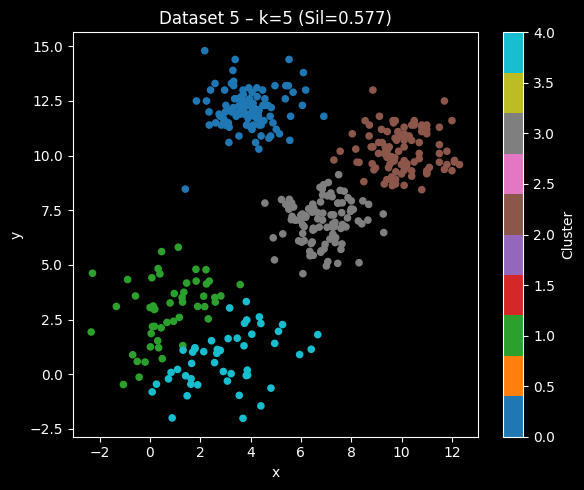

In [47]:
df5 = pd.read_csv("Dataset 5.csv", header=None, names=["x", "y"])
print(f"Dataset 5: {len(df5)} points")

best_k5, scores5 = find_best_k(df5.values)
print(f"Best k for Dataset 5: {best_k5}")
plot_silhouette_curve(scores5, "Dataset 5")

results5 = run_kmeans_and_save_results(df5, "Dataset5", best_k5)
for k, res in results5.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters(df5, res["labels"], f"Dataset 5 – k={k} (Sil={res['score']:.3f})")

## 8. Dataset 6

Dataset 6: 200 points
Best k for Dataset 6: 2


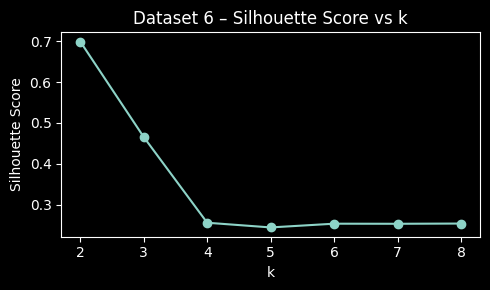

  k=2  |  Silhouette Score: 0.6989


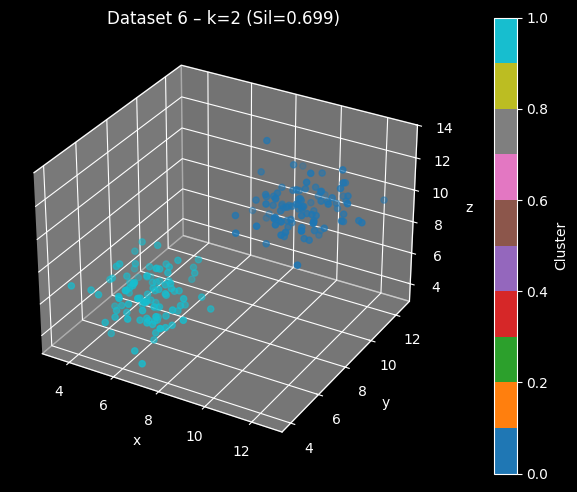

  k=3  |  Silhouette Score: 0.4652


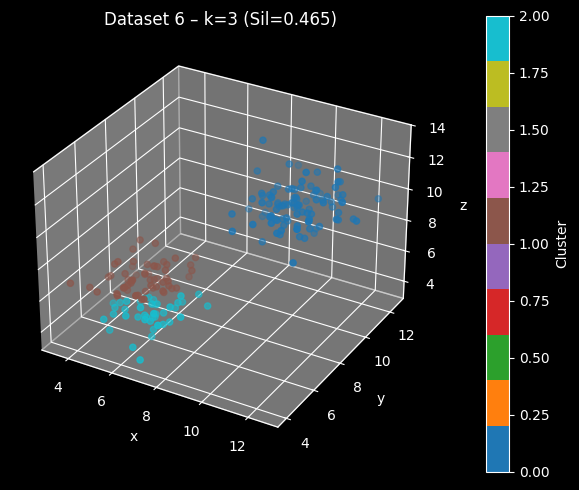

In [48]:
df6 = pd.read_csv("Dataset 6.csv", header=None, names=["x", "y", "z"])
print(f"Dataset 6: {len(df6)} points")

best_k6, scores6 = find_best_k(df6.values)
print(f"Best k for Dataset 6: {best_k6}")
plot_silhouette_curve(scores6, "Dataset 6")

results6 = run_kmeans_and_save_results(df6, "Dataset6", best_k6)
for k, res in results6.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters_3d(df6, res["labels"], f"Dataset 6 – k={k} (Sil={res['score']:.3f})")

## 9. Dataset 7

Dataset 7: 200 points
Best k for Dataset 7: 2


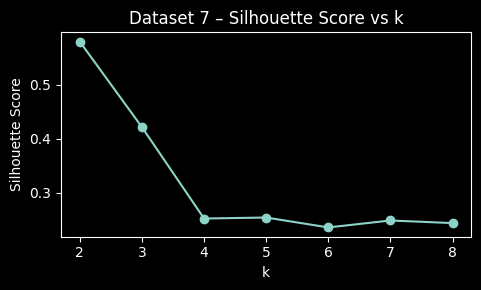

  k=2  |  Silhouette Score: 0.5796


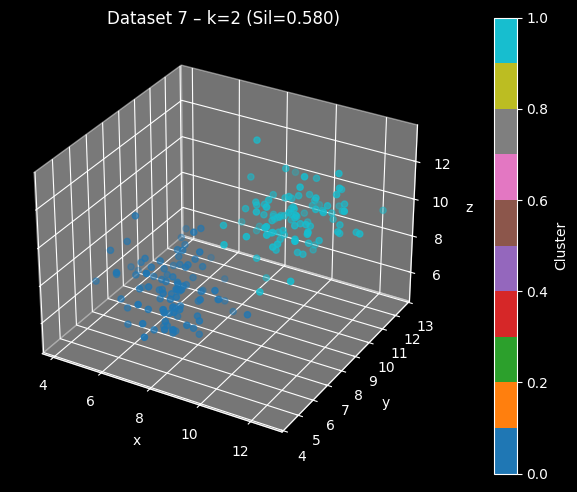

  k=3  |  Silhouette Score: 0.4212


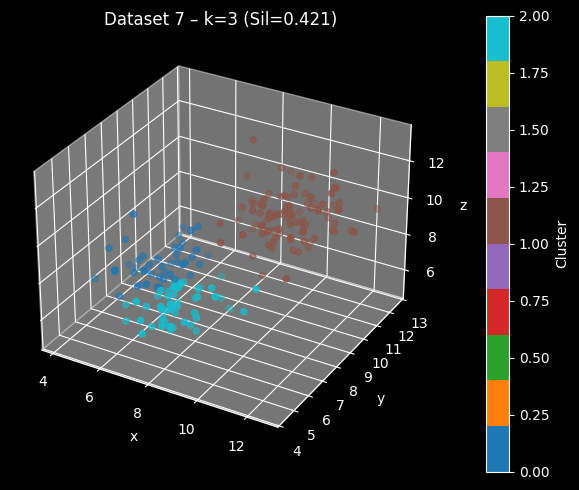

In [49]:
df7 = pd.read_csv("Dataset 7.csv", header=None, names=["x", "y", "z"])
print(f"Dataset 7: {len(df7)} points")

best_k7, scores7 = find_best_k(df7.values)
print(f"Best k for Dataset 7: {best_k7}")
plot_silhouette_curve(scores7, "Dataset 7")

results7 = run_kmeans_and_save_results(df7, "Dataset7", best_k7)
for k, res in results7.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters_3d(df7, res["labels"], f"Dataset 7 – k={k} (Sil={res['score']:.3f})")